# Pychenette n° 8 : Performances de plotly express vs graph_objects

**Pychenette** est une série de notebooks, en français, courts et originaux avec Python.

**Auteur** : Francis Wolinski

Pour tout commentaire : pychenette[at]yotta-conseil.fr

## L'idée de ce notebook

A l'occasion du développement d'un dashboard, je me suis rendu compte que **plotly.express** était nettement plus lent que **plotly.graph_objects**.

Ce notebook essaie d'évaluer les performances des deux modules proposés dans la librairie **plotly**.

Il utilise également les librairies **polars** et **pandas** pour asseoir les comparaisons.

In [1]:
# imports
import time

import pandas as pd
import polars as pl
import polars.selectors as cs

import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display
from great_tables import style, loc

### Les données utilisées

Nous utilisons le fichier des prénoms US de l'année 2024, en sélectionnant les 100 prénoms les plus fréquents.

In [2]:
# chargement des données

N_ROWS = 100

# polars
pl_df = (pl.read_csv("yob2024.txt", has_header=False, new_columns=["name", "gender", "births"])
         .top_k(N_ROWS, by="births")
         )

# pandas
pd_df = (pd.read_csv("yob2024.txt", header=None, names=["name", "gender", "births"])
         .nlargest(N_ROWS, "births")
         .reset_index(drop=True)
         )


### Graphique à produire

Il s'agit d'un graphique en barres très simple réalisé soit avec **plotly.express** soit avec **plotly.graph_objects**.

Pour des raisons esthétiques, nous avons limité le nombre de prénoms à 50 et avons rajouté une couleur selon le genre des prénoms.

Dans les calculs de performances qui suivent, ces éléments ne sont pas mis en oeuvre.

#### Avec plotly.express

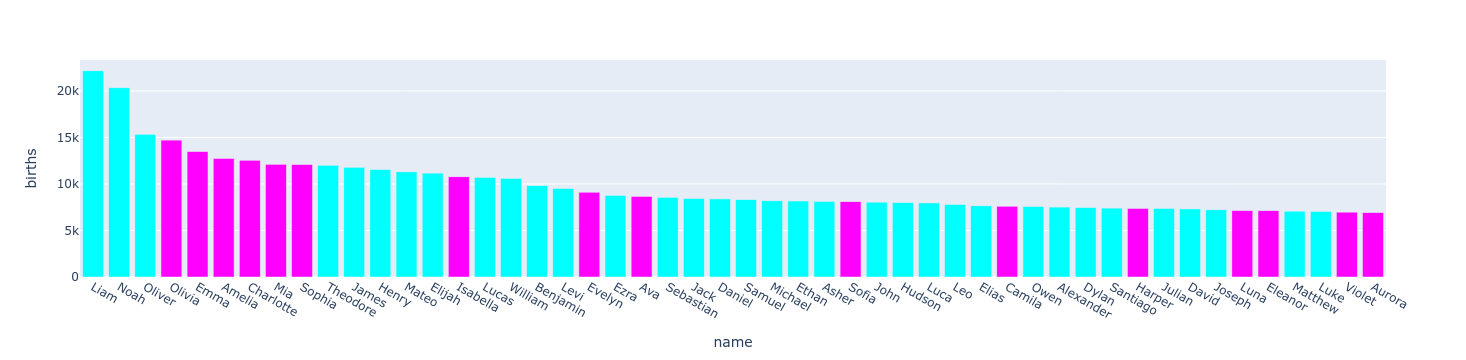

In [3]:
# plotly.express

colormap = {"M": "cyan", "F": "magenta"}
fig = px.bar(pl_df.head(50), x="name", y="births")
fig.update_traces(marker_color=[colormap[gender] for gender in pd_df["gender"].head(50)])
fig.show()

#### Avec plotly.graph_objects

Il faut rajouter les noms des axes pour obtenir un graphique similaire.

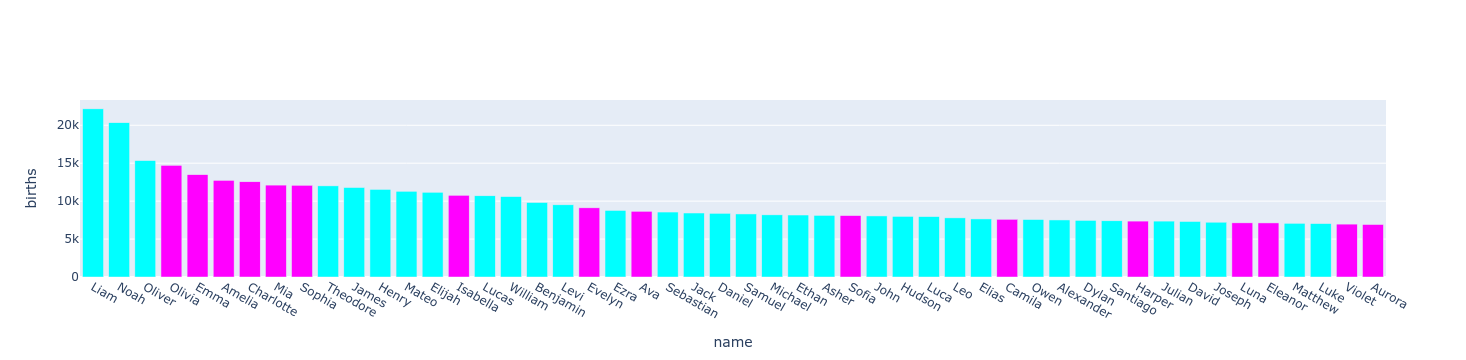

In [4]:
# plotly.graph_objects

fig = go.Figure(data=[go.Bar(x=pl_df["name"].head(50), y=pl_df["births"].head(50))])
fig.update_traces(marker_color=[colormap[gender] for gender in pl_df["gender"].head(50)])
fig.update_layout(xaxis_title="name", yaxis_title="births")
fig.show()

### Les fonctions de comparaison des performances

Nous allons effectuer des comparaisons de performances pour 4 utilisations et pour les 2 librairies **plotly** et **pandas** :
- **plotly.express** avec des dataframes
- **plotly.express** avec des colonnes
- **plotly.graph_objects** avec des colonnes
- **plotly.graph_objects** avec des listes

In [5]:
# px.bar with df
def bench_px_with_df(df, n):
    start = time.perf_counter()
    for _ in range(n):
        fig = px.bar(df, x="name", y="births")
    return (time.perf_counter() - start) / n

# px.bar with columns
def bench_px_with_columns(df, n):
    start = time.perf_counter()
    for _ in range(n):
        fig = px.bar(x=df["name"], y=df["births"])
        fig.update_layout(xaxis_title="name", yaxis_title="births")
    return (time.perf_counter() - start) / n

# go.Bar with columns
def bench_go_with_columns(df, n):
    start = time.perf_counter()
    for _ in range(n):
        fig = go.Figure(data=[go.Bar(x=df["name"], y=df["births"])])
        fig.update_layout(xaxis_title="name", yaxis_title="births")
    return (time.perf_counter() - start) / n

# go.Bar with lists
def bench_go_with_lists(df, n):
    start = time.perf_counter()
    for _ in range(n):
        fig = go.Figure(data=[go.Bar(x=df["name"].to_list(), y=df["births"].to_list())])
        fig.update_layout(xaxis_title="name", yaxis_title="births")
    return (time.perf_counter() - start) / n

### Exécution des tests

L'exécution des tests s'effectue avec un calcul initial de toutes les configurations.

On effectue 1.000 itérations avec **plotly.express** et 10.000 itérations avec **plotly.graph_objects**.

In [6]:
# Warm-up
fig = px.bar(pl_df, x="name", y="births")
fig = px.bar(pd_df, x="name", y="births")

fig = px.bar(x=pl_df["name"], y=pl_df["births"])
fig.update_layout(xaxis_title="name", yaxis_title="births")
fig = px.bar(x=pd_df["name"], y=pd_df["births"])
fig.update_layout(xaxis_title="name", yaxis_title="births")

fig = go.Figure(data=[go.Bar(x=pl_df["name"], y=pl_df["births"])])
fig.update_layout(xaxis_title="name", yaxis_title="births")
fig = go.Figure(data=[go.Bar(x=pd_df["name"], y=pd_df["births"])])
fig.update_layout(xaxis_title="name", yaxis_title="births")

fig = go.Figure(data=[go.Bar(x=pl_df["name"].to_list(), y=pl_df["births"].to_list())])
fig.update_layout(xaxis_title="name", yaxis_title="births")
fig = go.Figure(data=[go.Bar(x=pd_df["name"].to_list(), y=pd_df["births"].to_list())])
fig.update_layout(xaxis_title="name", yaxis_title="births")

# run 
times = []
N_ITER = 1_000

times.append(bench_px_with_df(pl_df, N_ITER))
times.append(bench_px_with_df(pd_df, N_ITER))

times.append(bench_px_with_columns(pl_df, N_ITER))
times.append(bench_px_with_columns(pd_df, N_ITER))

N_ITER = 10_000
times.append(bench_go_with_columns(pl_df, N_ITER))
times.append(bench_go_with_columns(pd_df, N_ITER))

times.append(bench_go_with_lists(pl_df, N_ITER))
times.append(bench_go_with_lists(pd_df, N_ITER))

In [7]:
# show results

results = pl.DataFrame({"library": ["polars", "pandas"] * 4,
                        "plotly": ["px + df"] * 2 + ["px + columns"] * 2 + ["go + columns"] * 2 + ["go + lists"] * 2,
                        "time per it.": times})

gt = (results
      .style
      .fmt_number(columns=["time per it."], decimals=4)
      .tab_style(style=style.text(weight="bold"), locations=loc.column_header())
)

display(gt)

library,plotly,time per it.
polars,px + df,0.0186
pandas,px + df,0.0188
polars,px + columns,0.0191
pandas,px + columns,0.0200
polars,go + columns,0.0016
pandas,go + columns,0.0019
polars,go + lists,0.0018
pandas,go + lists,0.0018


### Analyse des résultats

Sur cet exemple, il ressort que :

- **plotly.graph_objects** est environ 10 fois plus efficace que **plotly.express**,
- avec **plotly.express**, il vaut mieux utiliser des dataframes que des colonnes,
- avec **plotly.graph_objects**, il vaut mieux utiliser des colonnes que des listes,
- la librairie **polars** est généralement plus efficace que **pandas**, même sur cet exemple qui ne nécessite aucun calcul.

### En guise de conclusion

Le module **plotly.express** est utile pour produire rapidement des datavisualisations.

Le module **plotly.graph_objects** doit être mis en oeuvre pour des applications critiques ou bien lorsque les ressources disponibles sont limitées.

### Versions des librairies utilisées

In [8]:
import plotly

print("plotly:", plotly.__version__)
print("polars:", pl.__version__)
print("pandas:", pd.__version__)

plotly: 6.4.0
polars: 1.38.1
pandas: 2.3.3
